In [ ]:
import os
from nilearn import plotting, image
from nilearn.maskers import NiftiLabelsMasker
from nilearn.masking import apply_mask, unmask
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import nibabel as nb
import pandas as pd
import seaborn as sns
from nilearn.image import load_img

windows = True

#paths
if windows:
    base_dir = "P:/workspaces/lg-ukbiobank/projects/"
else:
    base_dir = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"

nifti_path=os.path.join(base_dir, "nifti_avg")

In [2]:
def get_modal_values_per_region(atlas_img, value_img):
    """
    Get the most frequently occurring value from value_img within each region of atlas_img.
    Includes automatic registration to ensure images are properly aligned.
    
    Parameters:
    -----------
    atlas_img : nilearn image
        Atlas image with labeled regions (each region has a unique integer ID)
    value_img : nilearn image  
        Image containing values to find the mode of within each atlas region
        
    Returns:
    --------
    numpy.ndarray
        Array where index corresponds to atlas region ID and value is the most 
        frequent value from value_img in that region. Index 0 corresponds to 
        background/region 0.
    """
    import numpy as np
    from collections import Counter
    from nilearn import image
    
    # Check if images have identical affines and shapes
    atlas_shape = atlas_img.shape
    value_shape = value_img.shape
    atlas_affine = atlas_img.affine
    value_affine = value_img.affine
    
    print(f"Atlas shape: {atlas_shape}, Value image shape: {value_shape}")
    print(f"Affines match: {np.allclose(atlas_affine, value_affine, atol=1e-3)}")
    
    # If shapes or affines don't match, resample value_img to atlas_img space
    if (atlas_shape != value_shape or 
        not np.allclose(atlas_affine, value_affine, atol=1e-3)):
        
        print("Images not aligned - resampling value image to atlas space...")
        
        # Resample value_img to match atlas_img space
        value_img_resampled = image.resample_to_img(
            value_img, 
            atlas_img, 
            interpolation='nearest'  # Use nearest neighbor for categorical data
        )
        
        print(f"Resampled value image shape: {value_img_resampled.shape}")
        value_data = value_img_resampled.get_fdata()
    else:
        print("Images already aligned - proceeding without resampling")
        value_data = value_img.get_fdata()
    
    # Get atlas data
    atlas_data = atlas_img.get_fdata().astype(int)
    
    # Final check that shapes match
    if atlas_data.shape != value_data.shape:
        raise ValueError(f"After resampling, shapes still don't match: "
                        f"atlas {atlas_data.shape} vs value {value_data.shape}")
    
    # Get unique region IDs (excluding 0 which is typically background)
    region_ids = np.unique(atlas_data)
    
    # Initialize result array - size based on max region ID + 1 for indexing
    modal_values = np.zeros(len(region_ids) + 1)
    
    # For each region, find the most frequent value
    for i, region_id in enumerate(region_ids):
        if region_id == 0:  # Skip background
            continue
            
        # Get mask for current region
        region_mask = atlas_data == region_id
        
        # Get values in this region
        region_values = value_data[region_mask]
        
        # Remove zeros and NaNs if present
        region_values = region_values[~np.isnan(region_values)]
        region_values = region_values[region_values != 0]
        
        if len(region_values) > 0:
            # Find most frequent value using Counter
            counter = Counter(region_values.astype(int))
            modal_value = counter.most_common(1)[0][0]
            modal_values[i] = modal_value
        else:
            modal_values[i] = 0  # No valid values found
            
    return modal_values

## Main PMAPS

In [3]:
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker

atlas_dir = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas"
#1. Download Yeo atlas in nifti
yeo_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\yeo_2011\Yeo_JNeurophysiol11_MNI152\Yeo2011_7Networks_MNI152_FreeSurferConformed1mm.nii.gz"
yeo_img = image.index_img(yeo_in, 0)
#2. Load Glasser nifti
atlas_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\MNI_Glasser_HCP_v1.0.nii.gz"
atlas_img = image.load_img(atlas_in)

#3. Get network annotations Glasser parcels -> apply Glasser atlas to Yeo
masker = NiftiLabelsMasker(labels_img=atlas_img)

#4. Apply Glasser to pmap
pmap_in_lifg = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g1_pmap_mean.nii.gz"
pmap_in_lstg = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g1_pmap_mean.nii.gz"
pmap_img_lifg = image.load_img(pmap_in_lifg)
pmap_img_lstg = image.load_img(pmap_in_lstg)
pmap_net_stats_lifg = masker.fit_transform(pmap_img_lifg)
pmap_net_stats_lstg = masker.fit_transform(pmap_img_lstg)


pmap_in_lifg_g1 = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g2_pmap_mean.nii.gz"
pmap_in_lstg_g1 = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g2_pmap_mean.nii.gz"
pmap_img_lifg_g1 = image.load_img(pmap_in_lifg_g1)
pmap_img_lstg_g1 = image.load_img(pmap_in_lstg_g1)
pmap_net_stats_lifg_g1 = masker.fit_transform(pmap_img_lifg_g1)
pmap_net_stats_lstg_g1 = masker.fit_transform(pmap_img_lstg_g1)




In [4]:
glasser_base = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\Glasser_parcels.csv"
glasser_parcel_annots = pd.read_csv(glasser_base)

modal_yeo_per_glasser = get_modal_values_per_region(atlas_img, yeo_img)

glasser_parcel_annots["yeo2011Net"] = modal_yeo_per_glasser[1:-1]
glasser_parcel_annots["LIFG_g1"] = pmap_net_stats_lifg.T
glasser_parcel_annots["LSTS_g1"] = pmap_net_stats_lstg.T
glasser_parcel_annots["LIFG_g2"] = pmap_net_stats_lifg_g1.T
glasser_parcel_annots["LSTS_g2"] = pmap_net_stats_lstg_g1.T

glasser_parcel_annots.to_csv(r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\figs_new\Glasser_pmap_loadings.csv")

Atlas shape: (193, 229, 193), Value image shape: (256, 256, 256)
Affines match: False
Images not aligned - resampling value image to atlas space...


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\2090777257.py:40: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  value_img_resampled = image.resample_to_img(
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


Resampled value image shape: (193, 229, 193)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g,
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:77: RuntimeWarning: divide by zero encountered in log10
  logp = -np.log10(p_value)



One-way ANOVA results for LIFG_g1:
F-statistic: 82.682
p-value: 0.0
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g,
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)



One-way ANOVA results for LSTS_g1:
F-statistic: 38.656
p-value: 5.382667661164487e-40
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g,
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:77: RuntimeWarning: divide by zero encountered in log10
  logp = -np.log10(p_value)



One-way ANOVA results for LIFG_g2:
F-statistic: 68.993
p-value: 0.0
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g,
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\1670019482.py:77: RuntimeWarning: divide by zero encountered in log10
  logp = -np.log10(p_value)



One-way ANOVA results for LSTS_g2:
F-statistic: 125.933
p-value: 0.0
*** Highly significant differences between networks (p < 0.001)


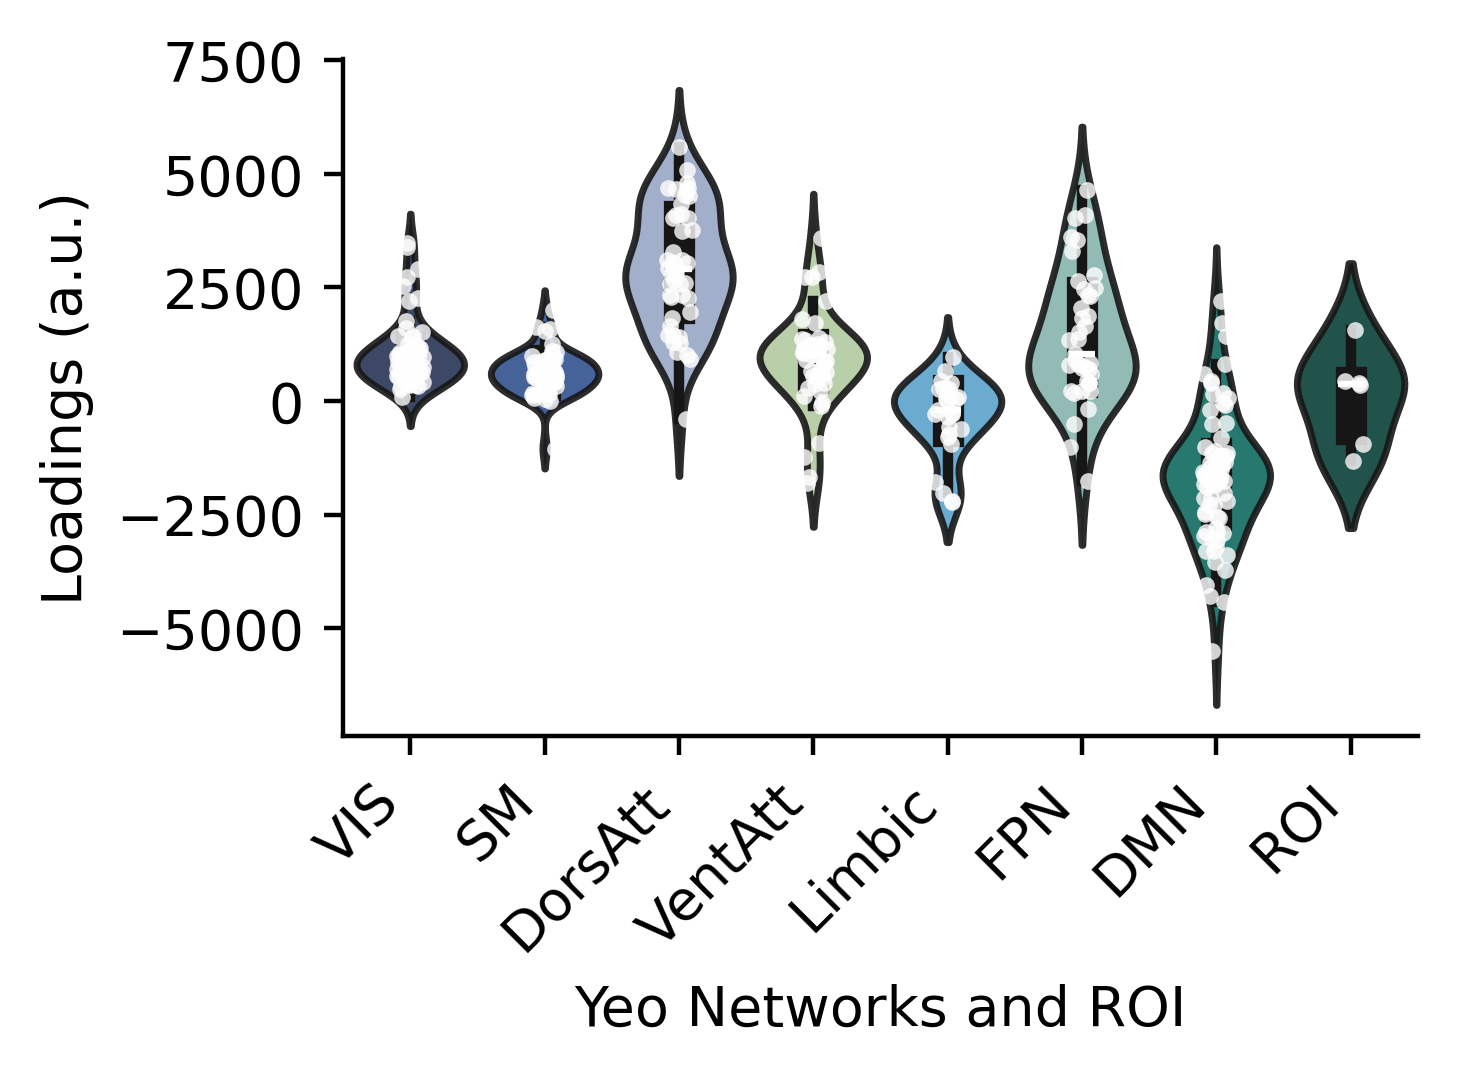

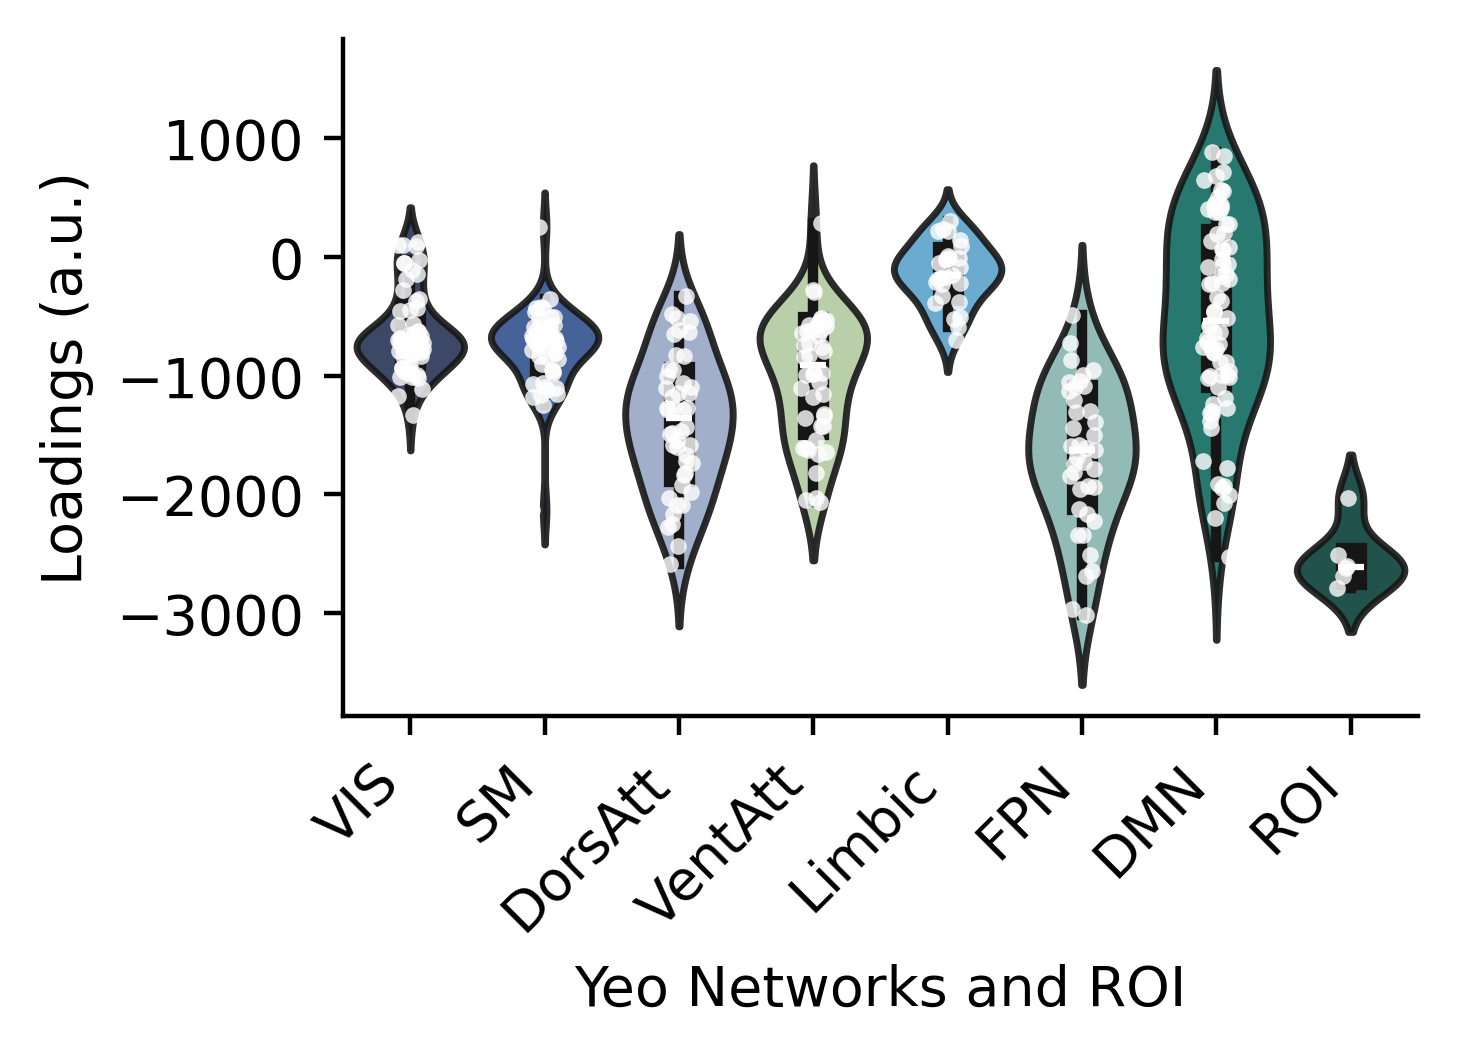

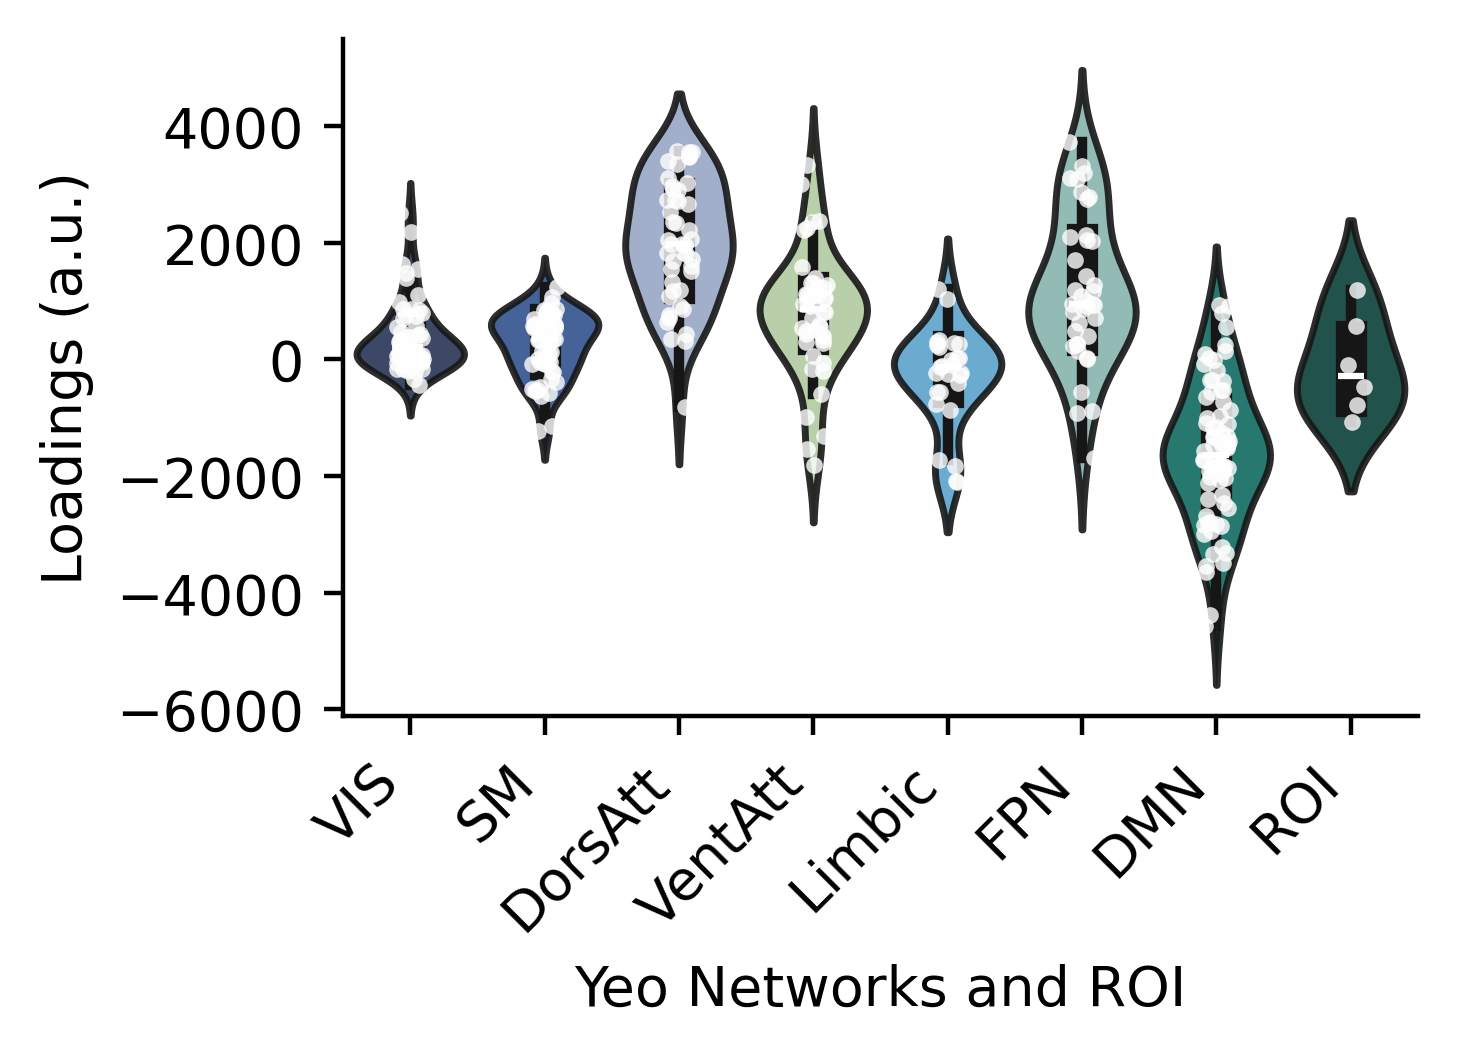

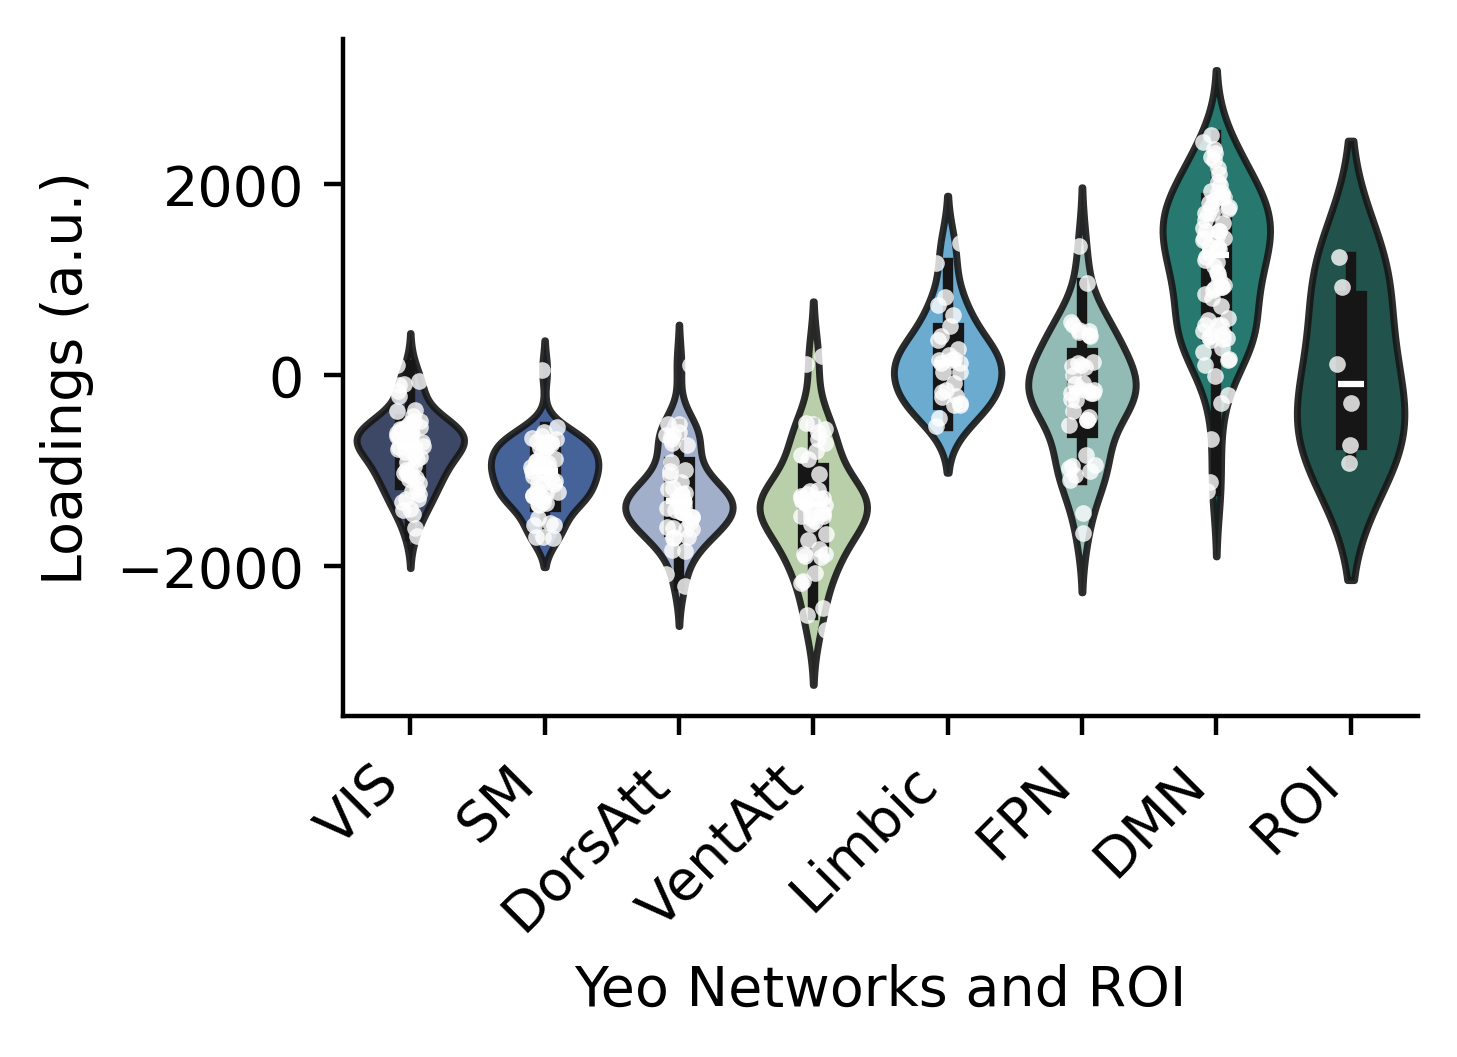

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize=(4,3)
pad=2

roi_lifg = [74, 75, 76, 79, 81, 82]
roi_lstg = [125, 128, 129, 130]
rois = roi_lifg + roi_lstg

colors = ["#20315B", "#214D9D", "#90A5CE", "#AFD199", "#49A7DE", "#80BBB4", "#00786A", "#00483F"] 

net_list = ["VIS", "SM", "DorsAtt", "VentAtt", "Limbic", "FPN", "DMN", "ROI"]

f_stats = []
p_vals = []
medians = []
stds = []

results_df = pd.DataFrame(columns=["{}_median".format(net) for net in net_list]+["{}_std".format(net) for net in net_list]+["ANOVA_F", "ANOVA_P", "ANOVA_LOG10P"], index=["Lifg_g0", "Lstg_g0",  "Lifg_g1", "Lstg_g1"])


for i, g in enumerate( ["LIFG_g1", "LSTS_g1",  "LIFG_g2", "LSTS_g2"]):

    
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=400)

    # Create a copy of the dataframe with an additional ROI category
    df_with_rois = glasser_parcel_annots.copy()
    
    # Determine which ROI to exclude based on the current map
    if g.startswith("Lifg"):  
        rois_to_exclude = roi_lifg
        rois_to_include = roi_lstg
    else: 
        rois_to_exclude = roi_lstg
        rois_to_include = roi_lifg
    
    # Remove the relevant ROIs from the dataframe
    df_with_rois = df_with_rois[~df_with_rois['regionID'].isin(rois_to_exclude)].copy()
    
    # Add ROI category (8) for the remaining specified regions
    df_with_rois['yeo2011Net_with_rois'] = df_with_rois['yeo2011Net'].copy()
    roi_mask = df_with_rois['regionID'].isin(rois_to_include)
    df_with_rois.loc[roi_mask, 'yeo2011Net_with_rois'] = 8

    # Create violin plot using seaborn
    sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g, 
                palette=colors, alpha=0.9, ax=ax)

    sns.stripplot(data=df_with_rois, x='yeo2011Net_with_rois', y=g,  
                color='white', alpha=0.8, size=3, ax=ax)

    # Customize the plot
    ax.set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Loadings (a.u.)', fontsize=10)
    ax.set_xlabel('Yeo Networks and ROI', fontsize=10)
    #ax.set_title('Gradient score loadings per network ({})'.format(g), fontsize=18, fontweight='bold')

    # Add grid for better readability
    #ax.grid(True, alpha=0.3, axis='y')
    #ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # Statistical test: ANOVA to test for differences between networks (including ROIs)
    from scipy import stats
    network_groups = [df_with_rois[df_with_rois['yeo2011Net_with_rois'] == float(net)][g].values 
                    for net in range(1, 9)]  # Changed to 9 to include ROIs category

    f_stat, p_value = stats.f_oneway(*network_groups)
    median = [np.median([n]) for n in [*network_groups]]
    stdev = [np.std([n]) for n in [*network_groups]]
    logp = -np.log10(p_value)

    results_df.iloc[i, :len(net_list)] = median
    results_df.iloc[i, len(net_list):len(net_list)*2] = stdev[i]
    results_df.iloc[i, len(net_list)*2:1+len(net_list)*2] = f_stat
    results_df.iloc[i, 1+len(net_list)*2:] = p_value
    results_df.iloc[i, 2+len(net_list)*2:] = logp

    print(f"\nOne-way ANOVA results for {g}:")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_value}")

    if p_value < 0.001:
        print("*** Highly significant differences between networks (p < 0.001)")
    elif p_value < 0.01:
        print("** Significant differences between networks (p < 0.01)")
    elif p_value < 0.05:
        print("* Significant differences between networks (p < 0.05)")
    else:
        print("No significant differences between networks (p >= 0.05)")

    plt.tight_layout(pad=pad)
    plt.savefig(os.path.join(base_dir, "figs_new", "fig_1_{0}_nets.svg".format(g)))
    plt.savefig(os.path.join(base_dir, "figs_new", "fig_1_{0}_nets.png".format(g)))

#Tails maps

In [7]:
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker
import glob
# load base annotations glasser parcels
glasser_base = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\Glasser_parcels.csv"
glasser_parcel_annots = pd.read_csv(glasser_base)

atlas_dir = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas"

#read Yeo networks nifti
yeo_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\yeo_2011\Yeo_JNeurophysiol11_MNI152\Yeo2011_7Networks_MNI152_FreeSurferConformed1mm.nii.gz"
yeo_img = image.index_img(yeo_in, 0)

#read Glasser atlas nifti
atlas_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\MNI_Glasser_HCP_v1.0.nii.gz"
atlas_img = image.load_img(atlas_in)

modal_yeo_per_glasser = get_modal_values_per_region(atlas_img, yeo_img)
glasser_parcel_annots["yeo2011Net"] = modal_yeo_per_glasser[1:-1]

#3. Get network annotations Glasser parcels -> apply Glasser atlas to Yeo
masker = NiftiLabelsMasker(labels_img=atlas_img)

#4. Apply Glasser to pmap
nifti_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_tails_cmaps"
nii_files_lower = sorted(glob.glob(os.path.join(nifti_path, "melodic_g1_cmap_*_oic_*_lower_pmap_mean.nii.gz")))
nii_files_middle = sorted(glob.glob(os.path.join(nifti_path, "melodic_g1_cmap_*_oic_*_middle_pmap_mean.nii.gz")))
nii_files_upper = sorted(glob.glob(os.path.join(nifti_path, "melodic_g1_cmap_*_oic_*_upper_pmap_mean.nii.gz")))

ic_labels = ["G1_LIFG_IC1", "G1_LIFG_IC2",  "G1_LIFG_IC3", "G1_LSTS_IC1", "G1_LSTS_IC2", "G1_LSTS_IC3"]

for roi, ic_map in zip(ic_labels, nii_files_lower):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_lower".format(roi)] = pmap_net_stats.T

for roi, ic_map in zip(ic_labels, nii_files_middle):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_middle".format(roi)] = pmap_net_stats.T

for roi, ic_map in zip(ic_labels, nii_files_upper):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_upper".format(roi)] = pmap_net_stats.T

nii_files_lower = sorted(glob.glob(os.path.join(nifti_path, "melodic_g2_cmap_*_oic_*_lower_pmap_mean.nii.gz")))
nii_files_middle = sorted(glob.glob(os.path.join(nifti_path, "melodic_g2_cmap_*_oic_*_middle_pmap_mean.nii.gz")))
nii_files_upper = sorted(glob.glob(os.path.join(nifti_path, "melodic_g2_cmap_*_oic_*_upper_pmap_mean.nii.gz")))

ic_labels = [lbl.replace("G1", "G2") for lbl in ic_labels]

for roi, ic_map in zip(ic_labels, nii_files_lower):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_lower".format(roi)] = pmap_net_stats.T

for roi, ic_map in zip(ic_labels, nii_files_middle):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_middle".format(roi)] = pmap_net_stats.T

for roi, ic_map in zip(ic_labels, nii_files_upper):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}_upper".format(roi)] = pmap_net_stats.T

net_dict = {1: "Visual", 2: "Somatomotor", 3:"Dorsal attention", 4: "Ventral attention", 5: "Limbic", 6: "Frontoparietal", 7: "Default mode"}


glasser_parcel_annots.to_csv(r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\figs_new\Glasser_results_tails.csv")

Atlas shape: (193, 229, 193), Value image shape: (256, 256, 256)
Affines match: False
Images not aligned - resampling value image to atlas space...


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\2090777257.py:40: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  value_img_resampled = image.resample_to_img(
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


Resampled value image shape: (193, 229, 193)


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\regions\signal_extraction.py:332: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(imgs, ensure_finite=True)
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\regions\signal_extraction.py:332: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(imgs, ensure_finite=True)
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\regions\signal_extraction.py:332: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(imgs, ensure_finite=True)
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\regions\signal_extraction.py:332: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(imgs, ensure_finite=True)
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\regions\signal_extraction.py:332: UserWar

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize=(3.5,12)
pad=3

roi_lifg = [74, 75, 76, 79, 81, 82]
roi_lstg = [125, 128, 129, 130]
rois = roi_lifg + roi_lstg

ic_labels = ["LIFG_IC1", "LIFG_IC2",  "LIFG_IC3", "LSTS_IC1", "LSTS_IC2", "LSTS_IC3"]

for tail in ["lower", "middle", "upper"]:

    for grad in ["g1", "g2"]:
        
        fig, ax = plt.subplots(6, 1, figsize=figsize, dpi=400)

        nii_files = sorted(glob.glob(os.path.join(nifti_path, f"melodic_{grad}_cmap_*_oic_*_{tail}_pmap_mean.nii.gz")))
        grad = grad.replace("g", "G")

        for i, (g, nii) in enumerate( zip(ic_labels, nii_files)):

            
            net_list = ["VIS", "SM", "DorsAtt", "VentAtt", "Limbic", "FPN", "DMN", "ROI"]

            #colors = ["#214D9D",  "#20315B", "#F7B682", "#00483F",  "#49A7DE", "#00786A", "#AFD199", "#FF6B6B"]
            colors = ["#20315B", "#214D9D", "#90A5CE", "#AFD199", "#49A7DE", "#80BBB4", "#00786A", "#00483F"] 

            # Create a copy of the dataframe with an additional ROI category
            df_with_rois = glasser_parcel_annots.copy()
            
            # Determine which ROI to exclude based on the current IC
            if g.startswith("LIFG"):  # For LifgIC1, LifgIC2, LifgIC3
                rois_to_exclude = roi_lifg
                rois_to_include = roi_lstg
            else:  # For LmtgIC1, LmtgIC2, LmtgIC3
                rois_to_exclude = roi_lstg
                rois_to_include = roi_lifg
            
            # Remove the relevant ROIs from the dataframe
            df_with_rois = df_with_rois[~df_with_rois['regionID'].isin(rois_to_exclude)].copy()
            
            # Add ROI category (8) for the remaining specified regions
            df_with_rois['yeo2011Net_with_rois'] = df_with_rois['yeo2011Net'].copy()
            roi_mask = df_with_rois['regionID'].isin(rois_to_include)
            df_with_rois.loc[roi_mask, 'yeo2011Net_with_rois'] = 8

            # Create violin plot using seaborn
            sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail), 
                        palette=colors, alpha=0.7, ax=ax[i])

            sns.stripplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),   
                        color='white', alpha=0.8, size=3, ax=ax[i])

            # Customize the plot
            ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
            ax[i].set_ylabel('Loadings (a.u.)', fontsize=10)
            ax[i].set_xlabel('', fontsize=10)
            #ax.set_title('Gradient score loadings per network ({})'.format(g), fontsize=18, fontweight='bold')

            # Add grid for better readability
            #ax.grid(True, alpha=0.3, axis='y')
            #ax.set_axisbelow(True)

            ax[i].spines['top'].set_visible(False)
            ax[i].spines['right'].set_visible(False)
            ax[i].spines['left'].set_visible(True)
            ax[i].spines['bottom'].set_visible(True)

            # Statistical test: ANOVA to test for differences between networks (including ROIs)
            from scipy import stats
            network_groups = [df_with_rois[df_with_rois['yeo2011Net_with_rois'] == float(net)]["{0}_{1}_{2}".format(grad, g, tail)].values 
                            for net in range(1, 9)]  # Changed to 9 to include ROIs category

            f_stat, p_value = stats.f_oneway(*network_groups)
            print(f"\nOne-way ANOVA results for {g}:")
            print(f"F-statistic: {f_stat:.3f}")
            print(f"p-value: {p_value:.2e}")

            if p_value < 0.001:
                print("*** Highly significant differences between networks (p < 0.001)")
            elif p_value < 0.01:
                print("** Significant differences between networks (p < 0.01)")
            elif p_value < 0.05:
                print("* Significant differences between networks (p < 0.05)")
            else:
                print("No significant differences between networks (p >= 0.05)")

        plt.tight_layout(pad=pad)
        plt.savefig(os.path.join(base_dir, "figs_new", f"fig_2_{grad}_nets_{tail}.svg"))
        plt.savefig(os.path.join(base_dir, "figs_new", f"fig_2_{grad}_nets_{tail}.png"))
        plt.close()

C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Te


One-way ANOVA results for LIFG_IC1:
F-statistic: 41.463
p-value: 2.97e-42
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LIFG_IC2:
F-statistic: 61.447
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),



One-way ANOVA results for LIFG_IC3:
F-statistic: 69.527
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC1:
F-statistic: 87.268
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assig

...


One-way ANOVA results for LIFG_IC1:
F-statistic: 88.223
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LIFG_IC2:
F-statistic: 53.749
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Te


One-way ANOVA results for LIFG_IC3:
F-statistic: 13.480
p-value: 2.07e-15
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC1:
F-statistic: 70.514
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="{0}_{1}_{2}".format(grad, g, tail),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_24916\533737988.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)



One-way ANOVA results for LSTS_IC2:
F-statistic: 83.961
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC3:
F-statistic: 48.680
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


## Independent components

In [7]:
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker

# load base annotations glasser parcels
glasser_base = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\Glasser_parcels.csv"
glasser_parcel_annots = pd.read_csv(glasser_base)

atlas_dir = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas"

#read Yeo networks nifti
yeo_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\yeo_2011\Yeo_JNeurophysiol11_MNI152\Yeo2011_7Networks_MNI152_FreeSurferConformed1mm.nii.gz"
yeo_img = image.index_img(yeo_in, 0)

#read Glasser atlas nifti
atlas_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\MNI_Glasser_HCP_v1.0.nii.gz"
atlas_img = image.load_img(atlas_in)

modal_yeo_per_glasser = get_modal_values_per_region(atlas_img, yeo_img)
glasser_parcel_annots["yeo2011Net"] = modal_yeo_per_glasser[1:-1]

#3. Get network annotations Glasser parcels -> apply Glasser atlas to Yeo
masker = NiftiLabelsMasker(labels_img=atlas_img)

#4. Apply Glasser to pmap
nifti_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\ic_maps"
lifg_img = os.path.join(nifti_path, "g1_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g1_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]

for roi, ic_map in zip(["G1_LIFG_IC1", "G1_LIFG_IC2",  "G1_LIFG_IC3", "G1_LSTS_IC1", "G1_LSTS_IC2", "G1_LSTS_IC3"], nii_files):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}".format(roi)] = pmap_net_stats.T

net_dict = {1: "Visual", 2: "Somatomotor", 3:"Dorsal attention", 4: "Ventral attention", 5: "Limbic", 6: "Frontoparietal", 7: "Default mode"}


glasser_parcel_annots.to_csv(r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\figs_new\Glasser_results_ic_maps_G1.csv")

Atlas shape: (193, 229, 193), Value image shape: (256, 256, 256)
Affines match: False
Images not aligned - resampling value image to atlas space...


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\2090777257.py:40: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  value_img_resampled = image.resample_to_img(
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


Resampled value image shape: (193, 229, 193)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:


One-way ANOVA results for LIFG_IC1:
F-statistic: 111.498
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LIFG_IC2:
F-statistic: 48.239
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),



One-way ANOVA results for LIFG_IC3:
F-statistic: 141.259
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC1:
F-statistic: 101.001
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is 


One-way ANOVA results for LSTS_IC2:
F-statistic: 106.556
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC3:
F-statistic: 64.227
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\1890056376.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)


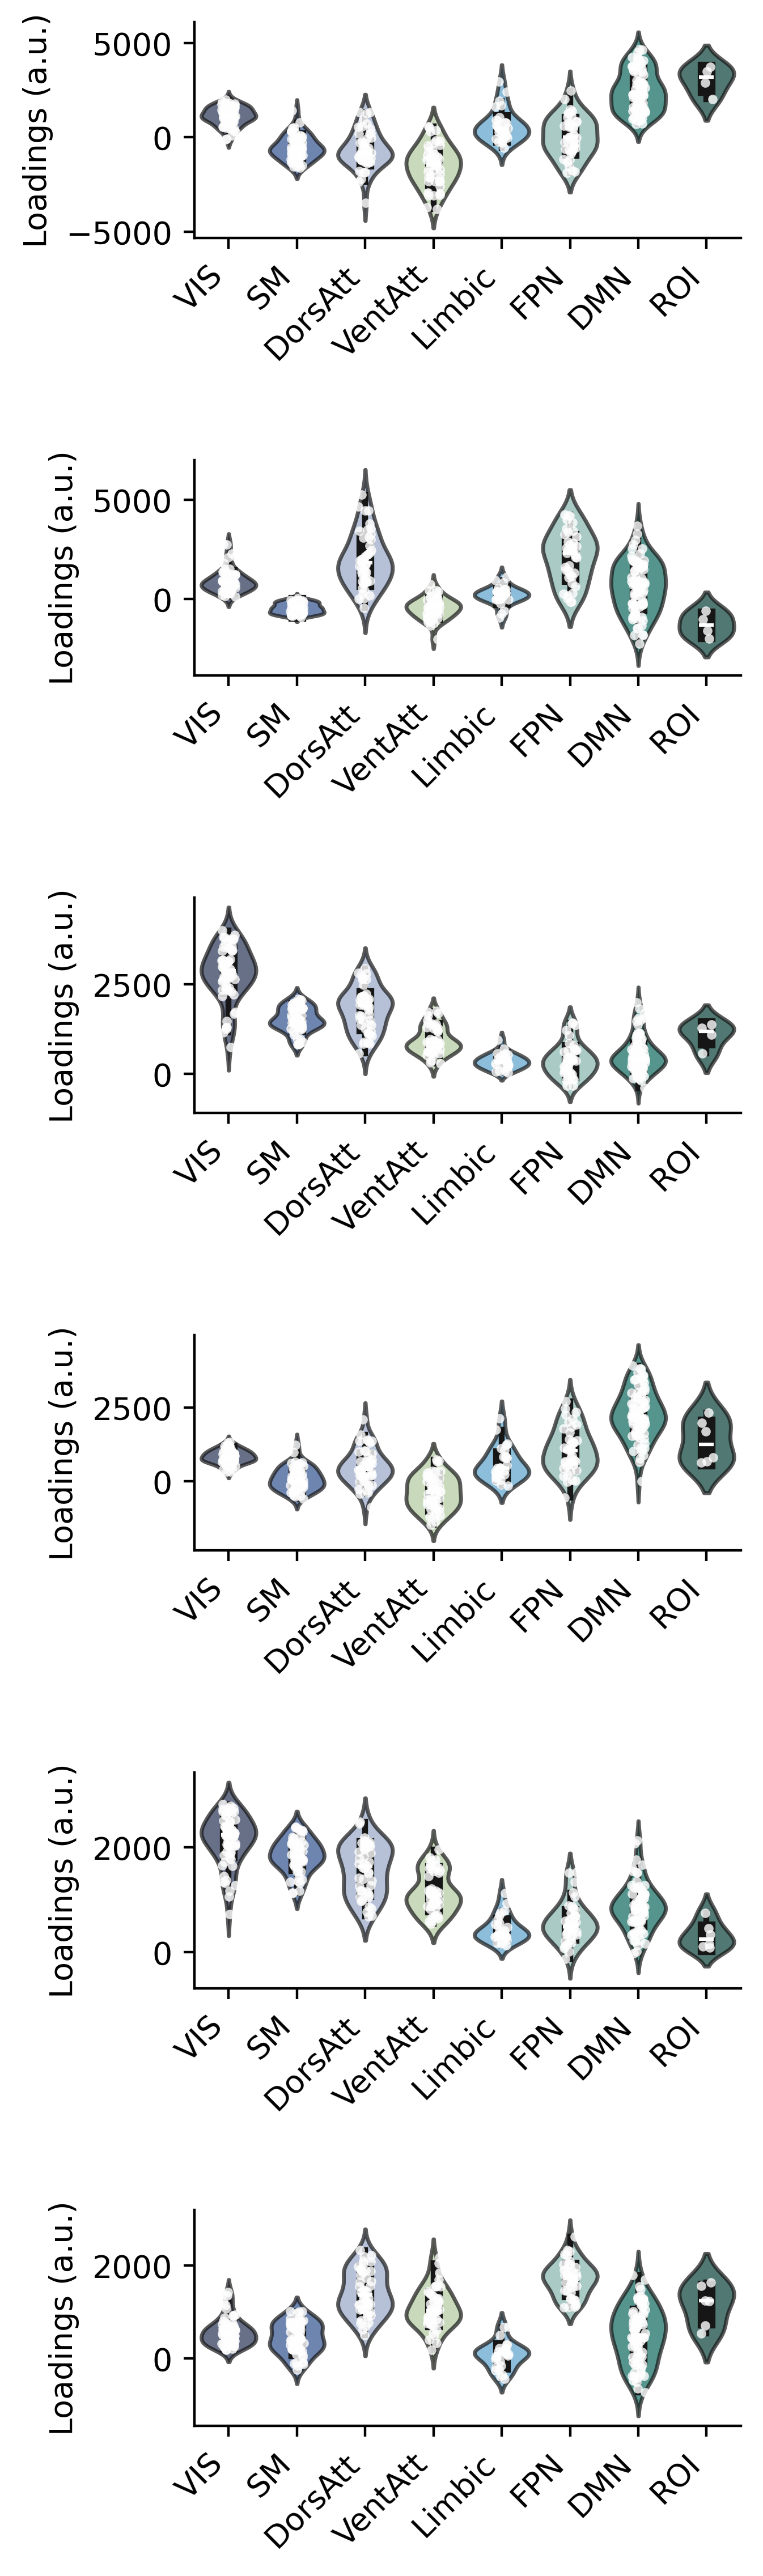

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize=(4,12)
pad=3

roi_lifg = [74, 75, 76, 79, 81, 82]
roi_lstg = [125, 128, 129, 130]
rois = roi_lifg + roi_lstg

fig, ax = plt.subplots(6, 1, figsize=figsize, dpi=400)

for i, (g, nii) in enumerate( zip(["LIFG_IC1", "LIFG_IC2",  "LIFG_IC3", "LSTS_IC1", "LSTS_IC2", "LSTS_IC3"], nii_files)):
    net_list = ["VIS", "SM", "DorsAtt", "VentAtt", "Limbic", "FPN", "DMN", "ROI"]

    #colors = ["#214D9D",  "#20315B", "#F7B682", "#00483F",  "#49A7DE", "#00786A", "#AFD199", "#FF6B6B"]
    colors = ["#20315B", "#214D9D", "#90A5CE", "#AFD199", "#49A7DE", "#80BBB4", "#00786A", "#00483F"] 

    # Create a copy of the dataframe with an additional ROI category
    df_with_rois = glasser_parcel_annots.copy()
    
    # Determine which ROI to exclude based on the current IC
    if g.startswith("LIFG"):  # For LifgIC1, LifgIC2, LifgIC3
        rois_to_exclude = roi_lifg
        rois_to_include = roi_lstg
    else:  # For LmtgIC1, LmtgIC2, LmtgIC3
        rois_to_exclude = roi_lstg
        rois_to_include = roi_lifg
    
    # Remove the relevant ROIs from the dataframe
    df_with_rois = df_with_rois[~df_with_rois['regionID'].isin(rois_to_exclude)].copy()
    
    # Add ROI category (8) for the remaining specified regions
    df_with_rois['yeo2011Net_with_rois'] = df_with_rois['yeo2011Net'].copy()
    roi_mask = df_with_rois['regionID'].isin(rois_to_include)
    df_with_rois.loc[roi_mask, 'yeo2011Net_with_rois'] = 8

    # Create violin plot using seaborn
    sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g), 
                palette=colors, alpha=0.7, ax=ax[i])

    sns.stripplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G1_{}".format(g),  
                color='white', alpha=0.8, size=3, ax=ax[i])

    # Customize the plot
    ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
    ax[i].set_ylabel('Loadings (a.u.)', fontsize=10)
    ax[i].set_xlabel('', fontsize=10)
    #ax.set_title('Gradient score loadings per network ({})'.format(g), fontsize=18, fontweight='bold')

    # Add grid for better readability
    #ax.grid(True, alpha=0.3, axis='y')
    #ax.set_axisbelow(True)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_visible(True)
    ax[i].spines['bottom'].set_visible(True)

    # Statistical test: ANOVA to test for differences between networks (including ROIs)
    from scipy import stats
    network_groups = [df_with_rois[df_with_rois['yeo2011Net_with_rois'] == float(net)]["G1_{}".format(g)].values 
                    for net in range(1, 9)]  # Changed to 9 to include ROIs category

    f_stat, p_value = stats.f_oneway(*network_groups)
    print(f"\nOne-way ANOVA results for {g}:")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_value:.2e}")

    if p_value < 0.001:
        print("*** Highly significant differences between networks (p < 0.001)")
    elif p_value < 0.01:
        print("** Significant differences between networks (p < 0.01)")
    elif p_value < 0.05:
        print("* Significant differences between networks (p < 0.05)")
    else:
        print("No significant differences between networks (p >= 0.05)")

plt.tight_layout(pad=pad)
plt.savefig(os.path.join(base_dir, "figs_new", "fig_2_g1_nets_all_with_rois_excluded.svg"))
plt.savefig(os.path.join(base_dir, "figs_new", "fig_2_g1_nets_all_with_rois_excluded.png"))

In [10]:
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker

# load base annotations glasser parcels
glasser_base = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\Glasser_parcels.csv"
glasser_parcel_annots = pd.read_csv(glasser_base)

atlas_dir = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas"

#read Yeo networks nifti
yeo_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\yeo_2011\Yeo_JNeurophysiol11_MNI152\Yeo2011_7Networks_MNI152_FreeSurferConformed1mm.nii.gz"
yeo_img = image.index_img(yeo_in, 0)

#read Glasser atlas nifti
atlas_in = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\atlas\MNI_Glasser_HCP_v1.0.nii.gz"
atlas_img = image.load_img(atlas_in)

modal_yeo_per_glasser = get_modal_values_per_region(atlas_img, yeo_img)
glasser_parcel_annots["yeo2011Net"] = modal_yeo_per_glasser[1:-1]

#3. Get network annotations Glasser parcels -> apply Glasser atlas to Yeo
masker = NiftiLabelsMasker(labels_img=atlas_img)

#4. Apply Glasser to pmap
nifti_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\ic_maps"
lifg_img = os.path.join(nifti_path, "g2_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g2_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]

for roi, ic_map in zip(["G2_LIFG_IC1", "G2_LIFG_IC2",  "G2_LIFG_IC3", "G2_LSTS_IC1", "G2_LSTS_IC2", "G2_LSTS_IC3"], nii_files):
    pmap_net_stats = masker.fit_transform(ic_map)
    glasser_parcel_annots["{}".format(roi)] = pmap_net_stats.T

net_dict = {1: "Visual", 2: "Somatomotor", 3:"Dorsal attention", 4: "Ventral attention", 5: "Limbic", 6: "Frontoparietal", 7: "Default mode"}


glasser_parcel_annots.to_csv(r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\figs_new\Glasser_results_ic_maps_G2.csv")

Atlas shape: (193, 229, 193), Value image shape: (256, 256, 256)
Affines match: False
Images not aligned - resampling value image to atlas space...


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\2090777257.py:40: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  value_img_resampled = image.resample_to_img(
c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


Resampled value image shape: (193, 229, 193)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g),



One-way ANOVA results for LIFG_IC1:
F-statistic: 92.539
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LIFG_IC2:
F-statistic: 48.615
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is depr


One-way ANOVA results for LIFG_IC3:
F-statistic: 143.057
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC1:
F-statistic: 102.308
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g),
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is depr


One-way ANOVA results for LSTS_IC2:
F-statistic: 126.340
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)

One-way ANOVA results for LSTS_IC3:
F-statistic: 63.578
p-value: 0.00e+00
*** Highly significant differences between networks (p < 0.001)


C:\Users\Jitse\AppData\Local\Temp\ipykernel_20708\412172454.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)


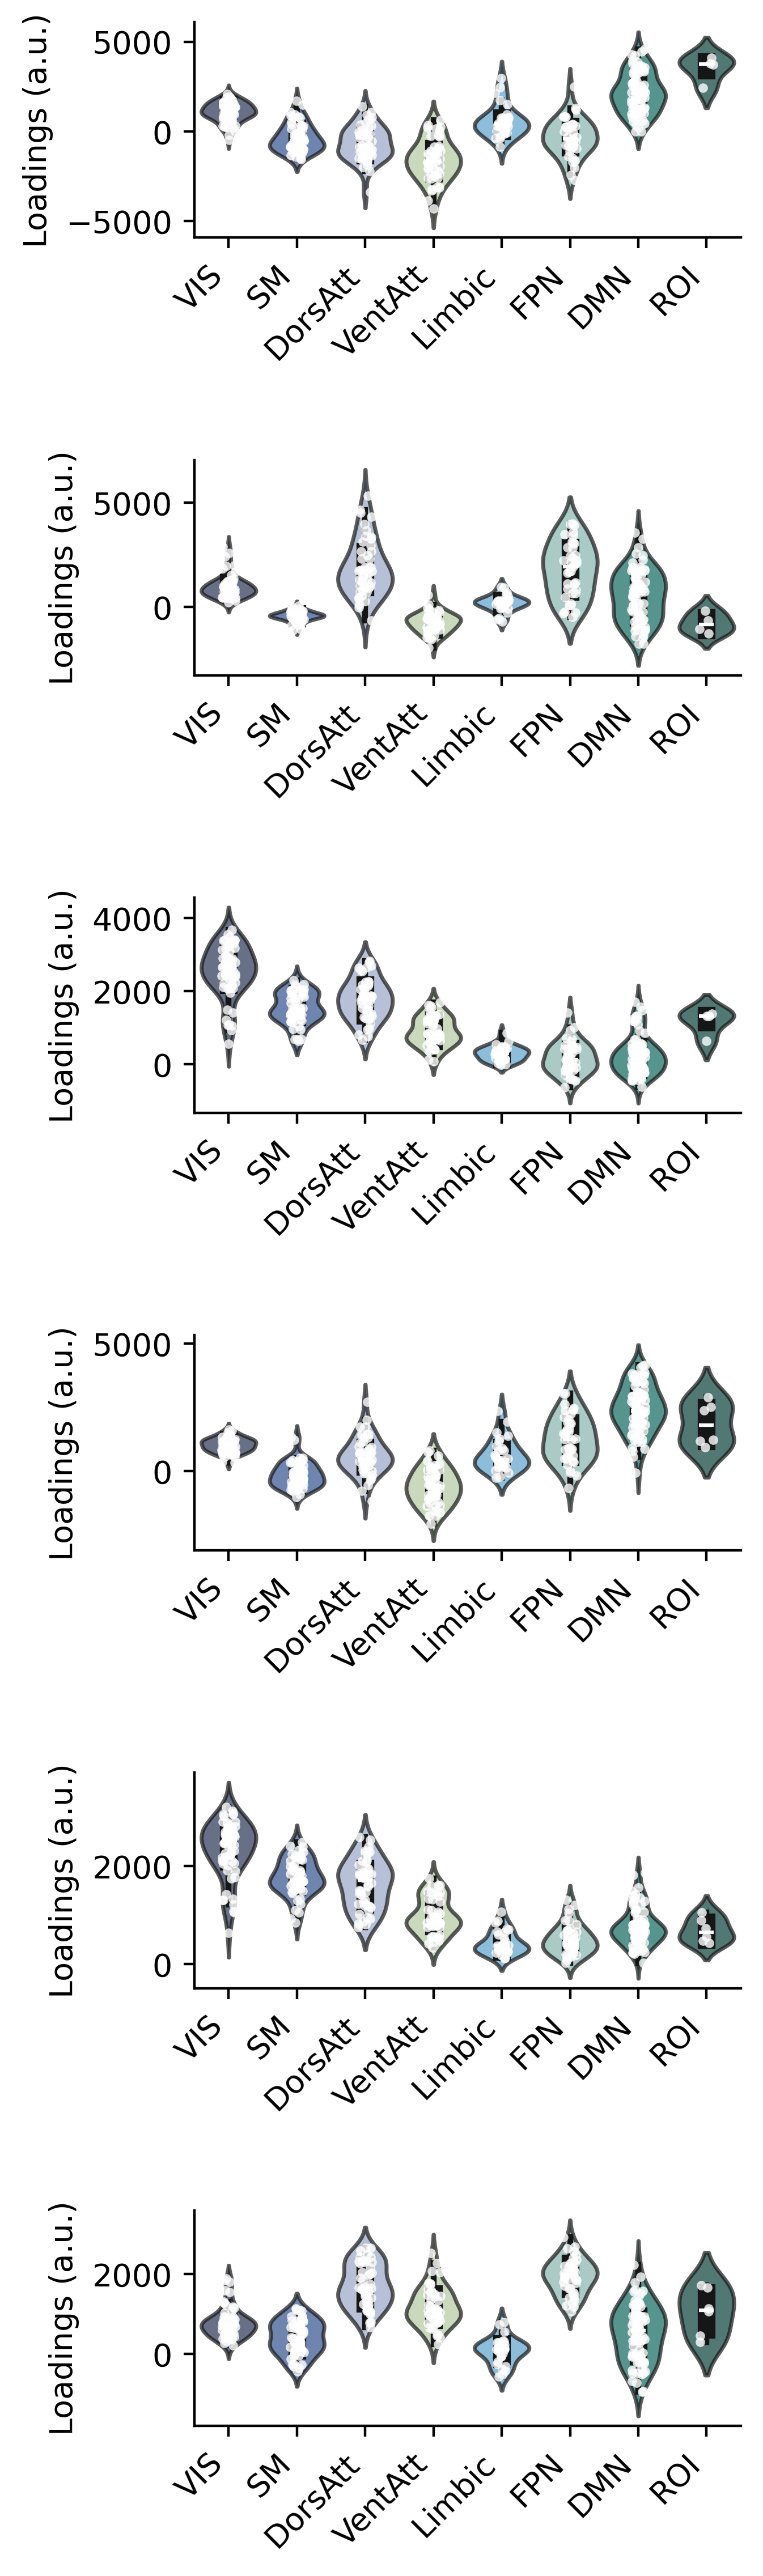

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize=(4,12)
pad=3

roi_lifg = [74, 75, 76, 79, 81, 82]
roi_lstg = [125, 128, 129, 130]
rois = roi_lifg + roi_lstg

fig, ax = plt.subplots(6, 1, figsize=figsize, dpi=400)

for i, (g, nii) in enumerate( zip(["LIFG_IC1", "LIFG_IC2",  "LIFG_IC3", "LSTS_IC1", "LSTS_IC2", "LSTS_IC3"], nii_files)):
    net_list = ["VIS", "SM", "DorsAtt", "VentAtt", "Limbic", "FPN", "DMN", "ROI"]

    #colors = ["#214D9D",  "#20315B", "#F7B682", "#00483F",  "#49A7DE", "#00786A", "#AFD199", "#FF6B6B"]
    colors = ["#20315B", "#214D9D", "#90A5CE", "#AFD199", "#49A7DE", "#80BBB4", "#00786A", "#00483F"] 

    # Create a copy of the dataframe with an additional ROI category
    df_with_rois = glasser_parcel_annots.copy()
    
    # Determine which ROI to exclude based on the current IC
    if g.startswith("LIFG"):  # For LifgIC1, LifgIC2, LifgIC3
        rois_to_exclude = roi_lifg
        rois_to_include = roi_lstg
    else:  # For LmtgIC1, LmtgIC2, LmtgIC3
        rois_to_exclude = roi_lstg
        rois_to_include = roi_lifg
    
    # Remove the relevant ROIs from the dataframe
    df_with_rois = df_with_rois[~df_with_rois['regionID'].isin(rois_to_exclude)].copy()
    
    # Add ROI category (8) for the remaining specified regions
    df_with_rois['yeo2011Net_with_rois'] = df_with_rois['yeo2011Net'].copy()
    roi_mask = df_with_rois['regionID'].isin(rois_to_include)
    df_with_rois.loc[roi_mask, 'yeo2011Net_with_rois'] = 8

    # Create violin plot using seaborn
    sns.violinplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g), 
                palette=colors, alpha=0.7, ax=ax[i])

    sns.stripplot(data=df_with_rois, x='yeo2011Net_with_rois', y="G2_{}".format(g),  
                color='white', alpha=0.8, size=3, ax=ax[i])

    # Customize the plot
    ax[i].set_xticklabels(net_list, rotation=45, ha='right', fontsize=10)
    ax[i].set_ylabel('Loadings (a.u.)', fontsize=10)
    ax[i].set_xlabel('', fontsize=10)
    #ax.set_title('Gradient score loadings per network ({})'.format(g), fontsize=18, fontweight='bold')

    # Add grid for better readability
    #ax.grid(True, alpha=0.3, axis='y')
    #ax.set_axisbelow(True)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_visible(True)
    ax[i].spines['bottom'].set_visible(True)

    # Statistical test: ANOVA to test for differences between networks (including ROIs)
    from scipy import stats
    network_groups = [df_with_rois[df_with_rois['yeo2011Net_with_rois'] == float(net)]["G2_{}".format(g)].values 
                    for net in range(1, 9)]  # Changed to 9 to include ROIs category

    f_stat, p_value = stats.f_oneway(*network_groups)
    print(f"\nOne-way ANOVA results for {g}:")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_value:.2e}")

    if p_value < 0.001:
        print("*** Highly significant differences between networks (p < 0.001)")
    elif p_value < 0.01:
        print("** Significant differences between networks (p < 0.01)")
    elif p_value < 0.05:
        print("* Significant differences between networks (p < 0.05)")
    else:
        print("No significant differences between networks (p >= 0.05)")

plt.tight_layout(pad=pad)
plt.savefig(os.path.join(base_dir, "figs_new", "fig_2_g2_nets_all_with_rois_excluded.svg"))
plt.savefig(os.path.join(base_dir, "figs_new", "fig_2_g2_nets_all_with_rois_excluded.png"))